In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train_and_test2.csv


In [2]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
)

pd.set_option("display.max_columns", 100)


In [3]:
# 1) Load Titanic
def load_titanic():
    try:
        df = sns.load_dataset("titanic")
        print("Loaded seaborn Titanic dataset.")
        return df
    except Exception:
        pass
    p = "/mnt/data/titanic.csv"
    if os.path.exists(p):
        df = pd.read_csv(p)
        print(f"Loaded local CSV from {p}.")
        return df
    raise FileNotFoundError("Could not load Titanic dataset from seaborn or /mnt/data/titanic.csv")

df = load_titanic()

Loaded seaborn Titanic dataset.


In [4]:
# 2) EDA (brief)
print("\n--- Shape ---")
print(df.shape)
print("\n--- Columns ---")
print(df.columns.tolist())
print("\n--- Missing values (top 10) ---")
print(df.isnull().sum().sort_values(ascending=False).head(10))
cols_to_describe = [c for c in ["age", "sex", "pclass", "fare"] if c in df.columns]
print("\n--- Key feature summary ---")
print(df[cols_to_describe].describe(include="all"))



--- Shape ---
(891, 15)

--- Columns ---
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

--- Missing values (top 10) ---
deck           688
age            177
embarked         2
embark_town      2
survived         0
pclass           0
sex              0
sibsp            0
parch            0
fare             0
dtype: int64

--- Key feature summary ---
               age   sex      pclass        fare
count   714.000000   891  891.000000  891.000000
unique         NaN     2         NaN         NaN
top            NaN  male         NaN         NaN
freq           NaN   577         NaN         NaN
mean     29.699118   NaN    2.308642   32.204208
std      14.526497   NaN    0.836071   49.693429
min       0.420000   NaN    1.000000    0.000000
25%      20.125000   NaN    2.000000    7.910400
50%      28.000000   NaN    3.000000   14.454200
75%      38.000000   NaN    3.000000   31.000000
max     

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


In [6]:
# 3) Target + features (consistent selection)
target = "survived"
feature_candidates = [
    "pclass", "sex", "age", "sibsp", "parch", "fare", "embarked",
    "who", "adult_male", "alone"
]
features = [c for c in feature_candidates if c in df.columns]
X = df[features].copy()
y = df[target].astype(int).copy()

In [7]:

# 4) Train/Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
# 5) Preprocessing
numeric_features = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
categorical_features = [c for c in X.columns if c not in numeric_features]

# Common preprocess (used by Tree/RF; scale not needed)
preprocess_common = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features),
    ]
)


In [9]:
# Preprocess for Logistic Regression (adds scaling to numeric only)
preprocess_lr = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical_features),
    ]
)

In [10]:
# 6) Decision Tree (entropy / information gain)
dt_pipe = Pipeline(steps=[
    ("prep", preprocess_common),
    ("model", DecisionTreeClassifier(criterion="entropy", random_state=42))
])
dt_pipe.fit(X_train, y_train)

# 7) Evaluation — Decision Tree
y_pred = dt_pipe.predict(X_test)
y_proba = dt_pipe.predict_proba(X_test)[:, 1]


In [11]:
print("\n=== Decision Tree (Entropy) — Evaluation ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred):.3f}")
print(f"F1-score : {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.3f}\n")
print(classification_report(y_test, y_pred, digits=3))



=== Decision Tree (Entropy) — Evaluation ===
Accuracy : 0.799
Precision: 0.754
Recall   : 0.710
F1-score : 0.731
ROC-AUC  : 0.771

              precision    recall  f1-score   support

           0      0.825     0.855     0.839       110
           1      0.754     0.710     0.731        69

    accuracy                          0.799       179
   macro avg      0.789     0.782     0.785       179
weighted avg      0.797     0.799     0.798       179



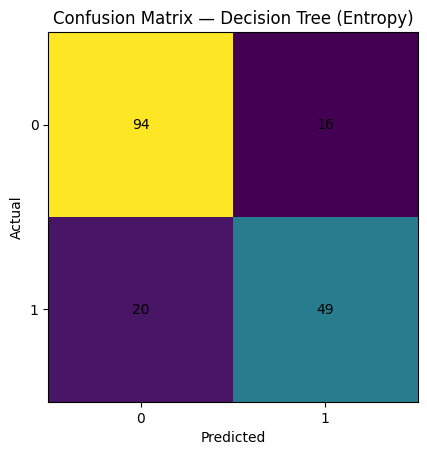

In [12]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots()
ax.imshow(cm, interpolation="nearest")
ax.set_title("Confusion Matrix — Decision Tree (Entropy)")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_xticks([0,1]); ax.set_yticks([0,1])
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, str(v), ha="center", va="center")
plt.show()

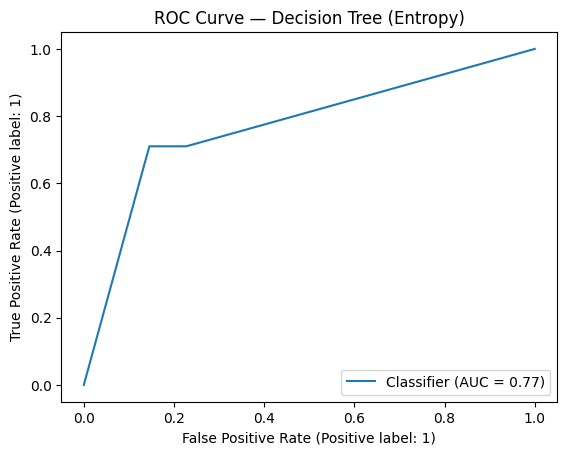

In [13]:
# ROC
fig, ax = plt.subplots()
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax)
ax.set_title("ROC Curve — Decision Tree (Entropy)")
plt.show()

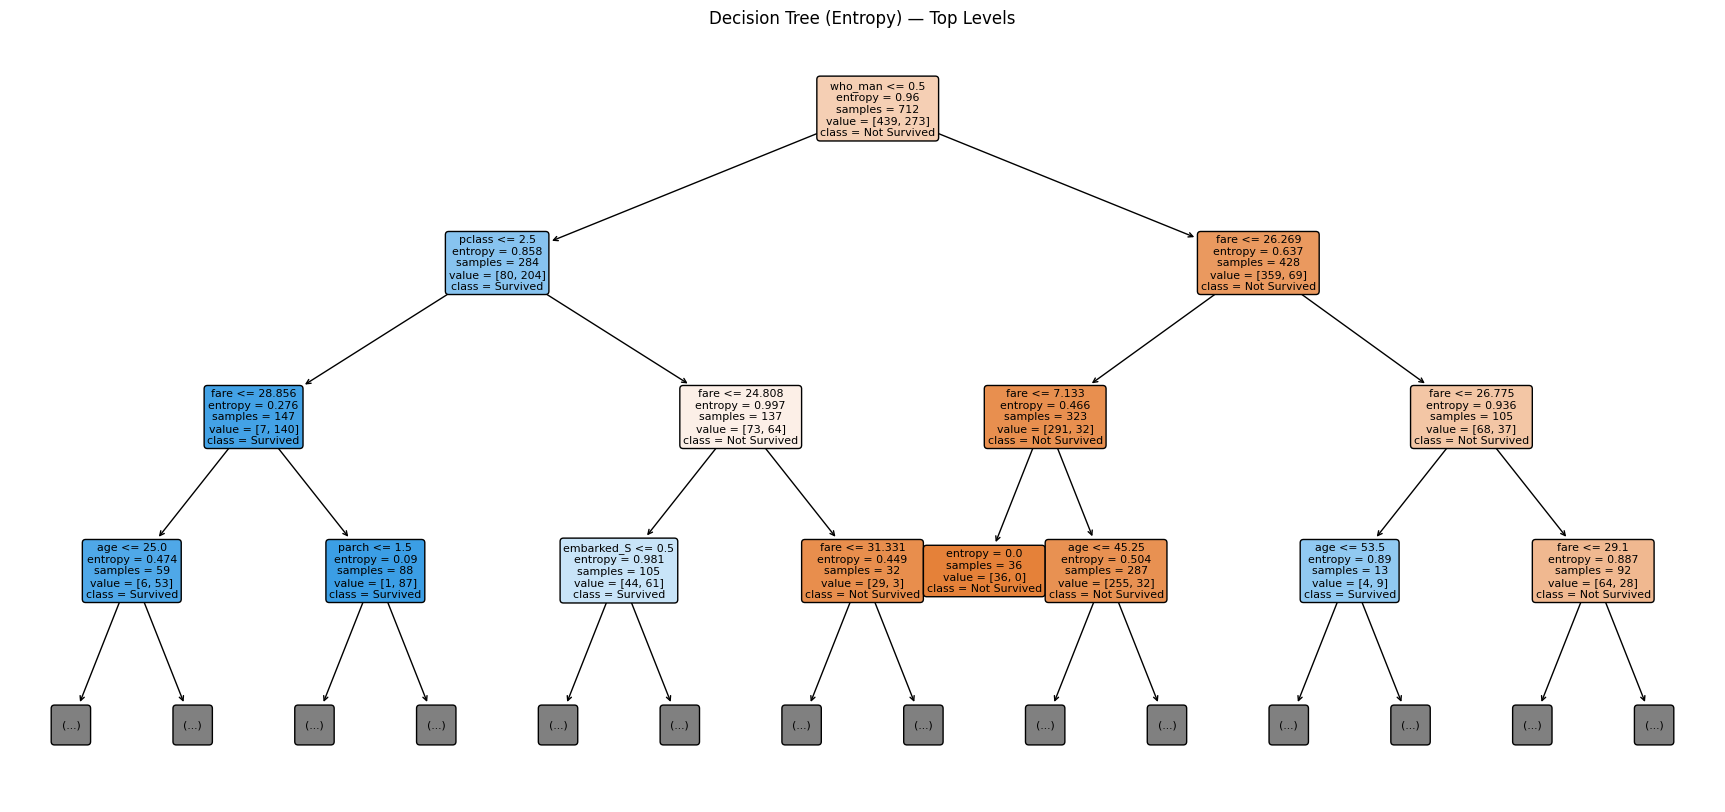

In [14]:
# 8) Visualize the Decision Tree (top levels for readability)
dt = dt_pipe.named_steps["model"]
ohe = dt_pipe.named_steps["prep"].named_transformers_["cat"].named_steps["onehot"]
encoded_cat_features = list(ohe.get_feature_names_out(categorical_features))
final_feature_names = numeric_features + encoded_cat_features

plt.figure(figsize=(22, 10))
plot_tree(
    dt,
    feature_names=final_feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True, rounded=True, impurity=True,
    max_depth=3  # adjust or remove to see more levels
)
plt.title("Decision Tree (Entropy) — Top Levels")
plt.show()


In [15]:
# 9) BONUS — Model comparison
models = {
    "Decision Tree (Entropy)": Pipeline([
        ("prep", preprocess_common),
        ("model", DecisionTreeClassifier(criterion="entropy", random_state=42))
    ]),
    "Logistic Regression": Pipeline([
        ("prep", preprocess_lr),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("prep", preprocess_common),
        ("model", RandomForestClassifier(n_estimators=300, random_state=42))
    ]),
}


In [16]:
rows = []
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    rows.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, pred), 3),
        "Precision": round(precision_score(y_test, pred), 3),
        "Recall": round(recall_score(y_test, pred), 3),
        "F1-score": round(f1_score(y_test, pred), 3),
        "ROC-AUC": round(roc_auc_score(y_test, proba), 3),
    })

comp = pd.DataFrame(rows).sort_values(by="Accuracy", ascending=False)
print("\n=== Model Comparison ===")
print(comp)


=== Model Comparison ===
                     Model  Accuracy  Precision  Recall  F1-score  ROC-AUC
1      Logistic Regression     0.838      0.812   0.754     0.782    0.869
2            Random Forest     0.832      0.810   0.739     0.773    0.834
0  Decision Tree (Entropy)     0.799      0.754   0.710     0.731    0.771


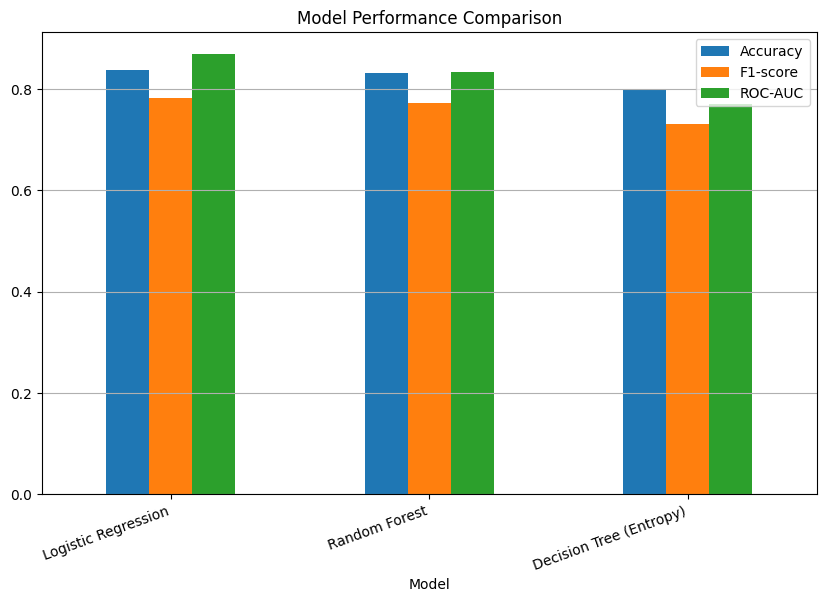

In [17]:
# Quick bar chart comparison
ax = comp.set_index("Model")[["Accuracy", "F1-score", "ROC-AUC"]].plot(
    kind="bar", figsize=(10, 6), title="Model Performance Comparison"
)
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y")
plt.show()